# Exploratory Data Analysis
Raw AI4Arctic Sea Ice Challenge Test Dataset

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import leafmap.leafmap as leafmap

## Load the data

In [5]:
data = xr.open_dataset("../S1A_EW_GRDM_1SDH_20180124T194759_20180124T194859_020301_022AA4_1F75_icechart_dmi_201801241950_SouthEast_RIC.nc", engine="netcdf4")
print(data)
print(list(data.data_vars))
print(data.dims)

<xarray.Dataset> Size: 2GB
Dimensions:                  (sar_lines: 10006, sar_samples: 10458,
                              sar_grid_points: 441, 2km_grid_lines: 200,
                              2km_grid_samples: 209, polygon_codes: 27)
Coordinates:
  * polygon_codes            (polygon_codes) <U56 6kB 'poly_id;CT;CA;SA;FA;CB...
Dimensions without coordinates: sar_lines, sar_samples, sar_grid_points,
                                2km_grid_lines, 2km_grid_samples
Data variables: (12/32)
    nersc_sar_primary        (sar_lines, sar_samples) float32 419MB ...
    nersc_sar_secondary      (sar_lines, sar_samples) float32 419MB ...
    polygon_icechart         (sar_lines, sar_samples) float32 419MB ...
    distance_map             (sar_lines, sar_samples) float32 419MB ...
    sar_grid_line            (sar_grid_points) float64 4kB ...
    sar_grid_sample          (sar_grid_points) float64 4kB ...
    ...                       ...
    u10m_rotated             (2km_grid_lines, 2km_grid_s

Key input features: `nersc_sar_primary` (HH), `nersc_sar_secondary` (HV), and `sar_grid_incidenceangle` (sparse 441-point vector — not a full image; the RTT dataset interpolates this to a full grid as `sar_incidenceangle`).

Target labels encoded in `polygon_icechart`:
- **SIC** — Sea Ice Concentration, ratio of ice to open water
- **SOD** — Stage of Development, ice type (proxy for thickness)
- **FLOE** — Floe Size, relevant to navigation

## Summary Statistics

In [4]:
rows = []
for v in data.data_vars:
    arr = data[v].values
    flat = arr.flatten().astype(float)
    valid = flat[~np.isnan(flat) & (flat != 255)]
    rows.append({
        'variable': v,
        'shape': str(arr.shape),
        'dtype': arr.dtype,
        'mean': np.mean(valid),
        'std': np.std(valid),
        'min': round(float(valid.min()),3) if len(valid) else None,
        'max': round(float(valid.max()),3) if len(valid) else None,
    })
display(pd.DataFrame(rows))

,variable,shape,dtype,mean,std,min,max
0,nersc_sar_primary,"(10006, 10458)",float32,-15.224570,6.048548,-83.149,19.607
1,nersc_sar_secondary,"(10006, 10458)",float32,-25.657054,4.476885,-83.462,27.609
2,polygon_icechart,"(10006, 10458)",float32,25.898525,5.055370,3.000,31.000
3,distance_map,"(10006, 10458)",float32,29.040578,12.566658,0.000,41.000
4,sar_grid_line,"(441,)",float64,5009.285714,3032.527504,0.000,10005.000
5,sar_grid_sample,"(441,)",float64,5229.857143,3166.686405,0.000,10457.000
6,sar_grid_latitude,"(441,)",float64,64.703523,1.102691,62.497,66.858
7,sar_grid_longitude,"(441,)",float64,-35.204997,2.660750,-40.704,-30.235
8,sar_grid_incidenceangle,"(441,)",float64,33.975946,8.297456,19.111,46.712
9,sar_grid_height,"(441,)",float64,0.000000,0.000000,0.000,0.000


## Visualization

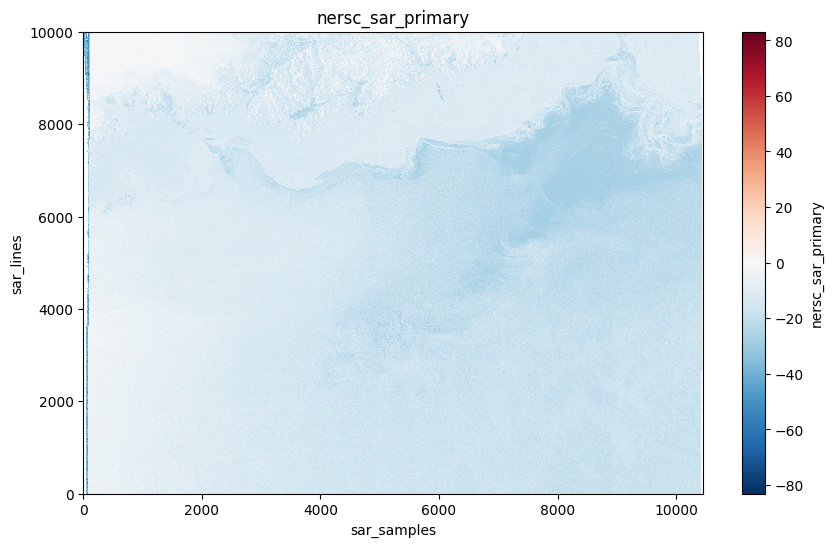

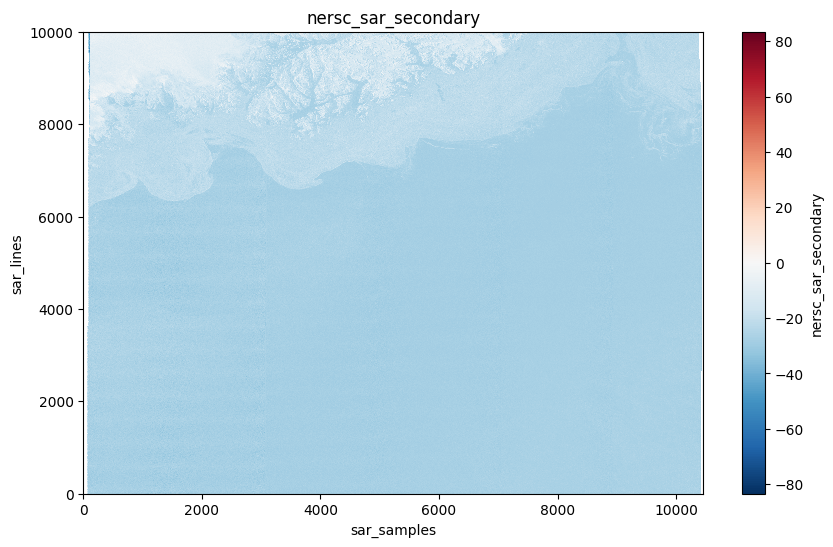

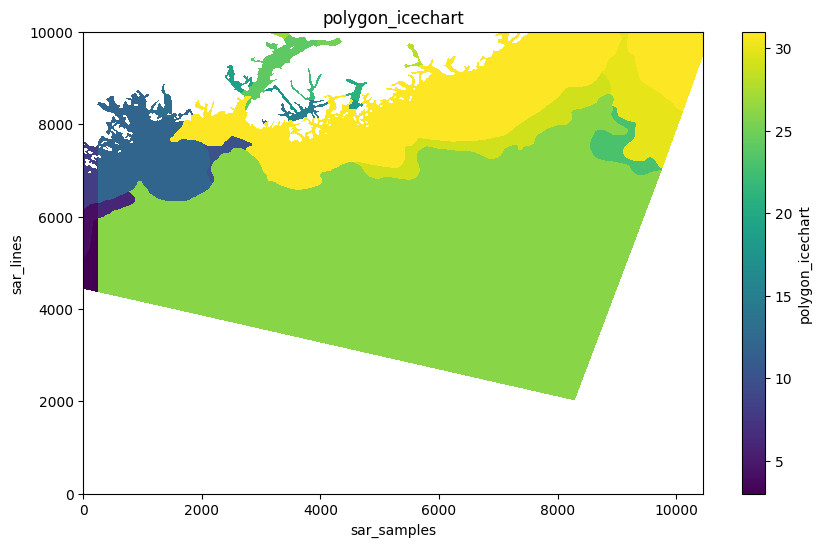

In [5]:
for var in ['nersc_sar_primary', 'nersc_sar_secondary', 'polygon_icechart']:
    plt.figure(figsize=(10, 6))
    data[var].plot()
    plt.title(var)
    plt.show()

## Visualize the SAR bands

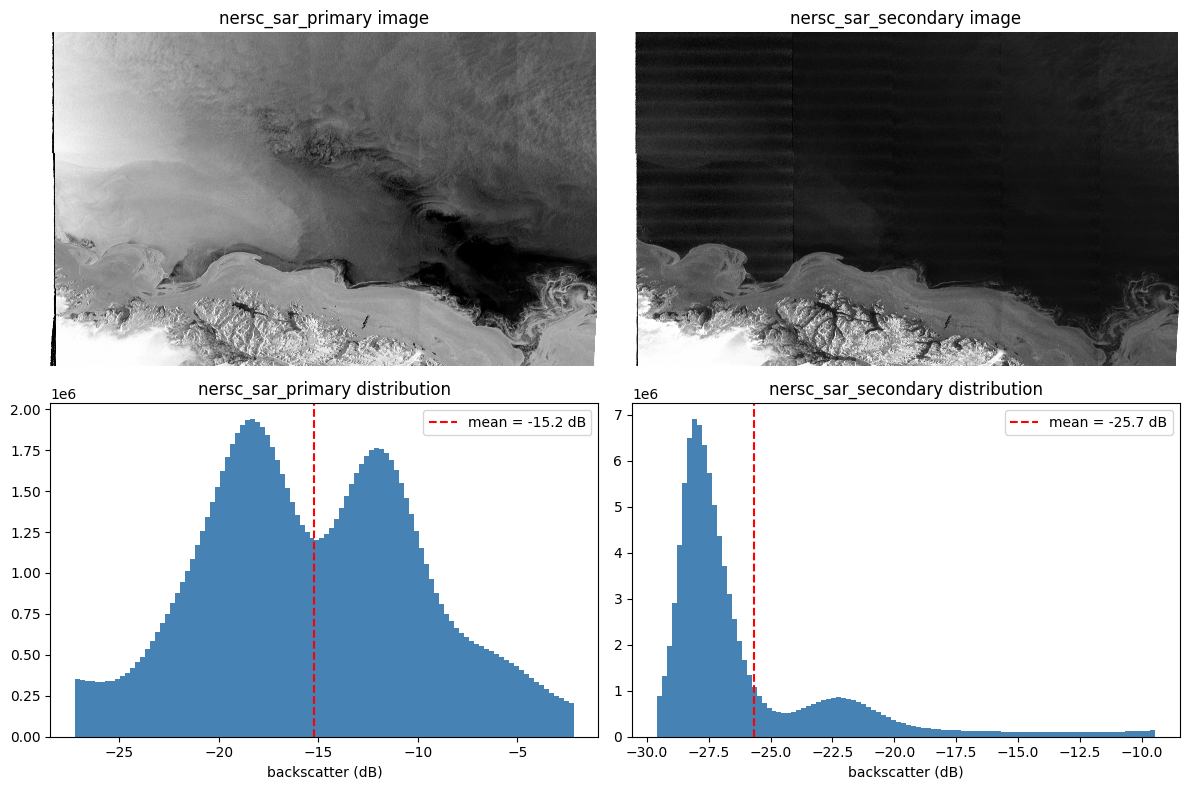

In [6]:
sar_vars = [v for v in ['nersc_sar_primary', 'nersc_sar_secondary'] if v in data]

fig, axes = plt.subplots(2, len(sar_vars), figsize=(12, 8))

for i, var in enumerate(sar_vars):
    pols = data[var].attrs.get('polarization', var) # reading "HH" or "HV"
    arr = data[var].values.astype(float)
    flat = arr[~np.isnan(arr)].flatten()      

    lo,hi = np.percentile(flat,2), np.percentile(flat,98)      

    img = np.clip((arr - lo) / (hi - lo), 0, 1) # normalize to [0,1]
    axes[0,i].imshow(img, cmap='gray', aspect='auto')
    axes[0,i].set_title(f'{pols} image')
    axes[0,i].axis('off')

    axes[1,i].hist(flat, bins=100, range=(lo, hi), color='steelblue')
    axes[1,i].axvline(flat.mean(), color='red', linestyle='dashed', label=f'mean = {flat.mean():.1f} dB')
    axes[1,i].set_xlabel("backscatter (dB)")
    axes[1,i].set_title(f'{pols} distribution')
    axes[1,i].legend()


plt.tight_layout()
plt.show()


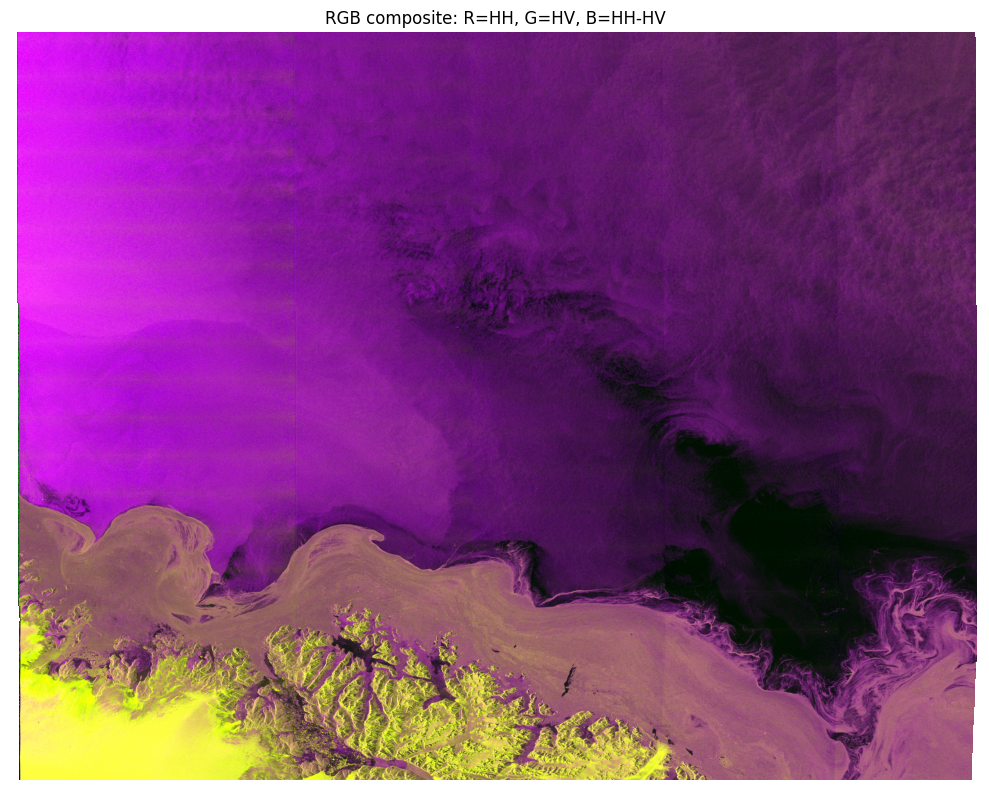

In [7]:
def norm(arr, lo=2, hi=98):
    a = arr.astype(float)
    lo_val = np.nanpercentile(a, lo)
    hi_val = np.nanpercentile(a, hi)
    return np.clip((a - lo_val) / (hi_val - lo_val), 0, 1)

hh  = data['nersc_sar_primary'].values.astype(float)
hv  = data['nersc_sar_secondary'].values.astype(float)

ratio = hh - hv
ratio[np.isnan(hh) | np.isnan(hv)] = np.nan

R = norm(hh)
G = norm(hv)
B = norm(ratio)

rgb = np.dstack([R, G, B])
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(rgb, aspect='auto')
ax.set_title('RGB composite: R=HH, G=HV, B=HH-HV')
ax.axis('off')
plt.tight_layout()
plt.show()

## Coefficient Correlation

In [ ]:
import seaborn as sns

# Block-average SAR to the 2km AMSR2 grid — each output pixel is the mean of
# an (rs × cs) patch, making the spatial scale comparable to AMSR2/ERA5.
h, w   = data['nersc_sar_primary'].shape
h_g, w_g = 200, 209
rs, cs = h // h_g, w // w_g

def block_mean(arr):
    a = arr.astype(float)
    return np.nanmean(a[:h_g*rs, :w_g*cs].reshape(h_g, rs, w_g, cs), axis=(1, 3))

hh = block_mean(data['nersc_sar_primary'].values)
hv = block_mean(data['nersc_sar_secondary'].values)

cols = {
    'SAR HH':   hh.flatten(),
    'SAR HV':   hv.flatten(),
    'HH-HV':    (hh - hv).flatten(),
    'BT 6.9H':  data['btemp_6_9h'].values.flatten(),
    'BT 6.9V':  data['btemp_6_9v'].values.flatten(),
    'BT 10.7H': data['btemp_10_7h'].values.flatten(),
    'BT 10.7V': data['btemp_10_7v'].values.flatten(),
    'BT 18.7H': data['btemp_18_7h'].values.flatten(),
    'BT 18.7V': data['btemp_18_7v'].values.flatten(),
    'BT 36.5H': data['btemp_36_5h'].values.flatten(),
    'BT 36.5V': data['btemp_36_5v'].values.flatten(),
    'BT 89H':   data['btemp_89_0h'].values.flatten(),
    'BT 89V':   data['btemp_89_0v'].values.flatten(),
    'wind_u':   data['u10m_rotated'].values.flatten(),
    'wind_v':   data['v10m_rotated'].values.flatten(),
    'T2m':      data['t2m'].values.flatten(),
    'SKT':      data['skt'].values.flatten(),
    'TCWV':     data['tcwv'].values.flatten(),
    'TCLW':     data['tclw'].values.flatten(),
}

df_corr = pd.DataFrame(cols).replace(255, np.nan).dropna()
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.4, ax=ax, annot_kws={'size': 8},
    vmin=-1, vmax=1,
)
ax.set_title('Feature Correlation Matrix (SAR block-averaged to 2 km grid)', fontsize=14)
plt.tight_layout()
plt.show()

- The brightness temperatures are highly correlated with each other
- Brightness temperatures and HH/HV bands are moderately correlated 
- T2m and SKT are highly correlated with each other. T2m, SKT, TCWV also have high correlation.

### Pearson correlation: the ratio between the covariance of two variables and the product of their standard deviation
1. Downsamples the SAR data
    SAR grid is 10000 x 10000 but AMSR2/ERA5 variables are only 200 × 209. To put everything in the same dataframe, we put it into the same spatial grid. We scale the SAR grid to 10000/200 and 10000/209 for roughly 50 rows/columns. This is called nearest-neighbour or point sampling.

2. Each variable is flattened from a 2D grid (200 x 209) into a 1D array. It is then turned into a dataframe where n/a values are dropped.

3. df_corr.corr() calculates the pearson correlation where red cells are strong positive correlations, blue are strong negative, white near zero. 

## Sea Ice Concentration

Decoding `polygon_icechart` using the `polygon_codes` coordinate, which maps each integer pixel value to a set of WMO ice chart attributes. The key field is **CT** (total concentration), coded 0–10 (tenths of ice coverage, where 0 = open water and 10 = fully ice-covered).

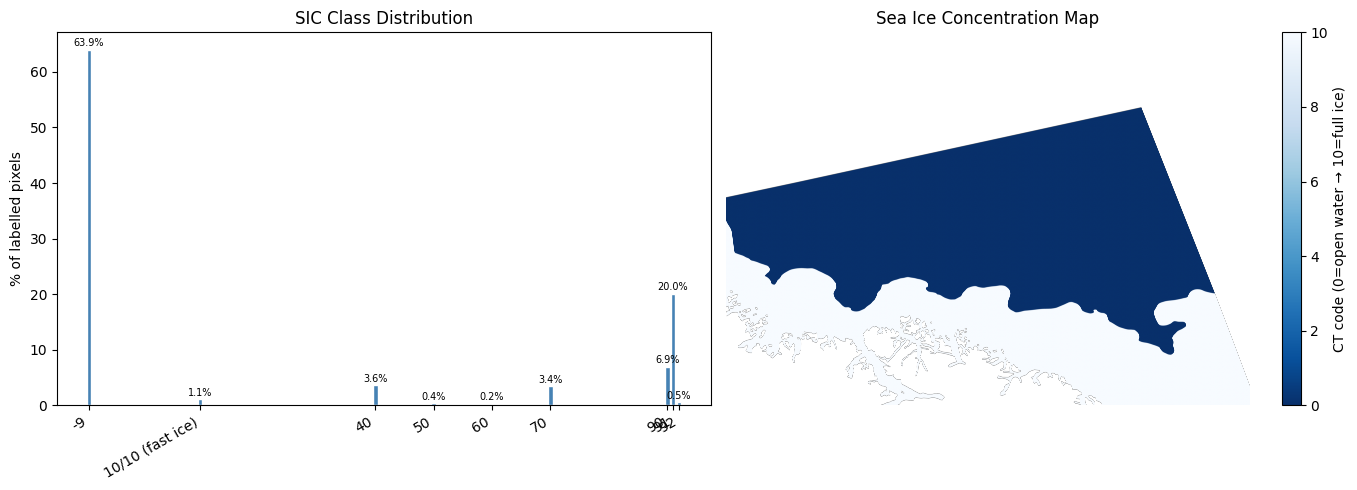

Ice-covered pixels: 36.1%
Open-water pixels:  63.9%


In [8]:
# Parse polygon_codes coordinate to build a poly_id → CT lookup
codes_raw = data.coords['polygon_codes'].values
header    = codes_raw[0].split(';')

records = []
for row in codes_raw[1:]:
    vals = row.split(';')
    records.append({k: v.strip() for k, v in zip(header, vals)})

legend = pd.DataFrame(records)
for col in legend.columns:
    legend[col] = pd.to_numeric(legend[col], errors='coerce')

sic_lookup = dict(zip(legend['poly_id'].astype(int), legend['CT']))

# Decode polygon_icechart pixels to CT (total concentration)
chart = data['polygon_icechart'].values.astype(float)
chart[chart == 255] = np.nan

sic_img = np.full_like(chart, np.nan)
for pid, ct in sic_lookup.items():
    sic_img[chart == pid] = ct

# Class distribution + spatial map
valid_sic = sic_img[~np.isnan(sic_img)].astype(int)
classes, counts = np.unique(valid_sic, return_counts=True)
pct = counts / counts.sum() * 100

# WMO CT codes used by the AI4Arctic challenge
ct_labels = {
    0: 'Open water', 1: 'Trace', 2: '1–3/10', 3: '4/10',
    4: '5/10',       5: '6/10', 6: '7/10',   7: '7–8/10',
    8: '8/10',       9: '9–10/10',            10: '10/10 (fast ice)',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(classes, pct, color='steelblue', edgecolor='white')
axes[0].set_xticks(classes)
axes[0].set_xticklabels([ct_labels.get(c, str(c)) for c in classes], rotation=30, ha='right')
axes[0].set_ylabel('% of labelled pixels')
axes[0].set_title('SIC Class Distribution')
for c, p in zip(classes, pct):
    axes[0].text(c, p + 0.3, f'{p:.1f}%', ha='center', va='bottom', fontsize=7)

im = axes[1].imshow(sic_img, cmap='Blues_r', vmin=0, vmax=10, aspect='auto')
plt.colorbar(im, ax=axes[1], label='CT code (0=open water → 10=full ice)')
axes[1].set_title('Sea Ice Concentration Map')
axes[1].axis('off')

plt.tight_layout()
plt.show()

ice_frac = (valid_sic > 0).sum() / len(valid_sic)
print(f"Ice-covered pixels: {ice_frac:.1%}")
print(f"Open-water pixels:  {1 - ice_frac:.1%}")

## Feature Correlation with Sea Ice Concentration

Downsampling `polygon_icechart` to the 2 km grid using the same stride as the SAR subsampling, then correlating each input feature against the decoded SIC (CT) value.

V-pol brightness temperatures are used here as they have a stronger physical relationship with ice concentration than H-pol at lower frequencies.

In [ ]:
# Block-average SAR and SIC image to the 2km grid
h, w     = data['nersc_sar_primary'].shape
h_g, w_g = 200, 209
rs, cs   = h // h_g, w // w_g

def block_mean(arr):
    a = arr.astype(float)
    return np.nanmean(a[:h_g*rs, :w_g*cs].reshape(h_g, rs, w_g, cs), axis=(1, 3))

hh_s  = block_mean(data['nersc_sar_primary'].values)
hv_s  = block_mean(data['nersc_sar_secondary'].values)
sic_s = block_mean(sic_img)

df_sl = pd.DataFrame({
    'SIC':      sic_s.flatten(),
    'SAR HH':   hh_s.flatten(),
    'SAR HV':   hv_s.flatten(),
    'HH-HV':    (hh_s - hv_s).flatten(),
    'BT 6.9V':  data['btemp_6_9v'].values.flatten(),
    'BT 18.7V': data['btemp_18_7v'].values.flatten(),
    'BT 36.5V': data['btemp_36_5v'].values.flatten(),
    'BT 89V':   data['btemp_89_0v'].values.flatten(),
}).dropna()

features = [c for c in df_sl.columns if c != 'SIC']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, features):
    ax.scatter(df_sl['SIC'], df_sl[col], alpha=0.3, s=5, color='steelblue')
    r = df_sl['SIC'].corr(df_sl[col])
    ax.set_xlabel('SIC (CT code)')
    ax.set_ylabel(col)
    ax.set_title(f'r = {r:.2f}')

plt.suptitle('Feature vs Sea Ice Concentration (SAR block-averaged to 2 km grid)', fontsize=13)
plt.tight_layout()
plt.show()

r_vals = df_sl.corr()['SIC'].drop('SIC').sort_values()
colors = ['tomato' if v < 0 else 'steelblue' for v in r_vals]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(r_vals.index, r_vals.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with SIC')
ax.set_title('Feature–SIC Correlation (single scene)')
plt.tight_layout()
plt.show()

## Scene Location

In [10]:
# sar_grid_latitude/longitude give us the 21x21 sparse grid covering the scene
lats = data['sar_grid_latitude'].values
lons = data['sar_grid_longitude'].values

center_lat = float(lats.mean())
center_lon = float(lons.mean())

m = leafmap.Map(center=[center_lat, center_lon], zoom=6)
m.add_basemap("OpenTopoMap")

bbox_geojson = {
    "type": "FeatureCollection",
    "features": [{
        "type": "Feature",
        "geometry": {
            "type": "Polygon",
            "coordinates": [[
                [float(lons.min()), float(lats.min())],
                [float(lons.max()), float(lats.min())],
                [float(lons.max()), float(lats.max())],
                [float(lons.min()), float(lats.max())],
                [float(lons.min()), float(lats.min())],
            ]]
        },
        "properties": {"name": "Scene footprint"}
    }]
}
m.add_geojson(bbox_geojson, layer_name="Scene footprint")
m

Map(center=[64.70352306915805, -35.20499727188743], controls=(ZoomControl(options=['position', 'zoom_in_text',…